In [ ]:
import pandas as pd

df = pd.read_csv('/content/combined_life_expectancy_mortality_data.csv')


print(df.head())


print("Concise summary of the DataFrame:")
df.info()

       country  year      status  life_expectancy_  adult_mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant_deaths  alcohol  percentage_expenditure  hepatitis_b  measles_  ...  \
0             62     0.01               71.279624         65.0      1154  ...   
1             64     0.01               73.523582         62.0       492  ...   
2             66     0.01               73.219243         64.0       430  ...   
3             69     0.01               78.184215         67.0      2787  ...   
4             71     0.01                7.097109         68.0      3013  ...   

   population  _thinness__1_19_years  _thinness_5_9_years  \
0  33736494.0            

In [ ]:

missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Values'] > 0].sort_values(by='Missing Percentage', ascending=False)
print(missing_info)

                                 Missing Values  Missing Percentage
unnamed:_5                                 2938          100.000000
specialnotes                               1815           61.776719
population                                  652           22.191967
hepatitis_b                                 553           18.822328
gdp                                         448           15.248468
incomegroup                                 435           14.805990
region                                      419           14.261402
total_expenditure                           226            7.692308
alcohol                                     194            6.603131
income_composition_of_resources             167            5.684139
schooling                                   163            5.547992
_bmi_                                        34            1.157250
_thinness__1_19_years                        34            1.157250
_thinness_5_9_years                          34 

In [ ]:

columns_to_drop = ['unnamed:_5', 'specialnotes']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)
    print(f"Dropped {existing_columns_to_drop} columns.")
else:
    print("Columns 'unnamed:_5' and 'specialnotes' already dropped or not present.")

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputed missing values in numerical column '{col}' with median: {median_val}")

for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Imputed missing values in categorical column '{col}' with mode: {mode_val}")

print("\nMissing values after handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("DataFrame info after missing value handling:")
df.info()

Dropped ['unnamed:_5', 'specialnotes'] columns.
Imputed missing values in numerical column 'alcohol' with median: 3.755
Imputed missing values in numerical column 'hepatitis_b' with median: 92.0
Imputed missing values in numerical column '_bmi_' with median: 43.5
Imputed missing values in numerical column 'polio' with median: 93.0
Imputed missing values in numerical column 'total_expenditure' with median: 5.755
Imputed missing values in numerical column 'diphtheria_' with median: 93.0
Imputed missing values in numerical column 'gdp' with median: 1766.947595
Imputed missing values in numerical column 'population' with median: 1386542.0
Imputed missing values in numerical column '_thinness__1_19_years' with median: 3.3
Imputed missing values in numerical column '_thinness_5_9_years' with median: 3.3
Imputed missing values in numerical column 'income_composition_of_resources' with median: 0.677
Imputed missing values in numerical column 'schooling' with median: 12.3
Imputed missing values

# **Insights on Life Expectancy Drivers**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

target_variable = 'life_expectancy_'
predictor_variables = ['gdp', 'schooling', 'adult_mortality', 'infant_mortality']

correlations = df[predictor_variables + [target_variable]].corr()[target_variable]

print("Pearson Correlation Coefficients with Life Expectancy:")
print(correlations.drop(target_variable))


Pearson Correlation Coefficients with Life Expectancy:
gdp                 0.430895
schooling           0.713738
adult_mortality    -0.696359
infant_mortality   -0.838497
Name: life_expectancy_, dtype: float64


Generating scatter plots...


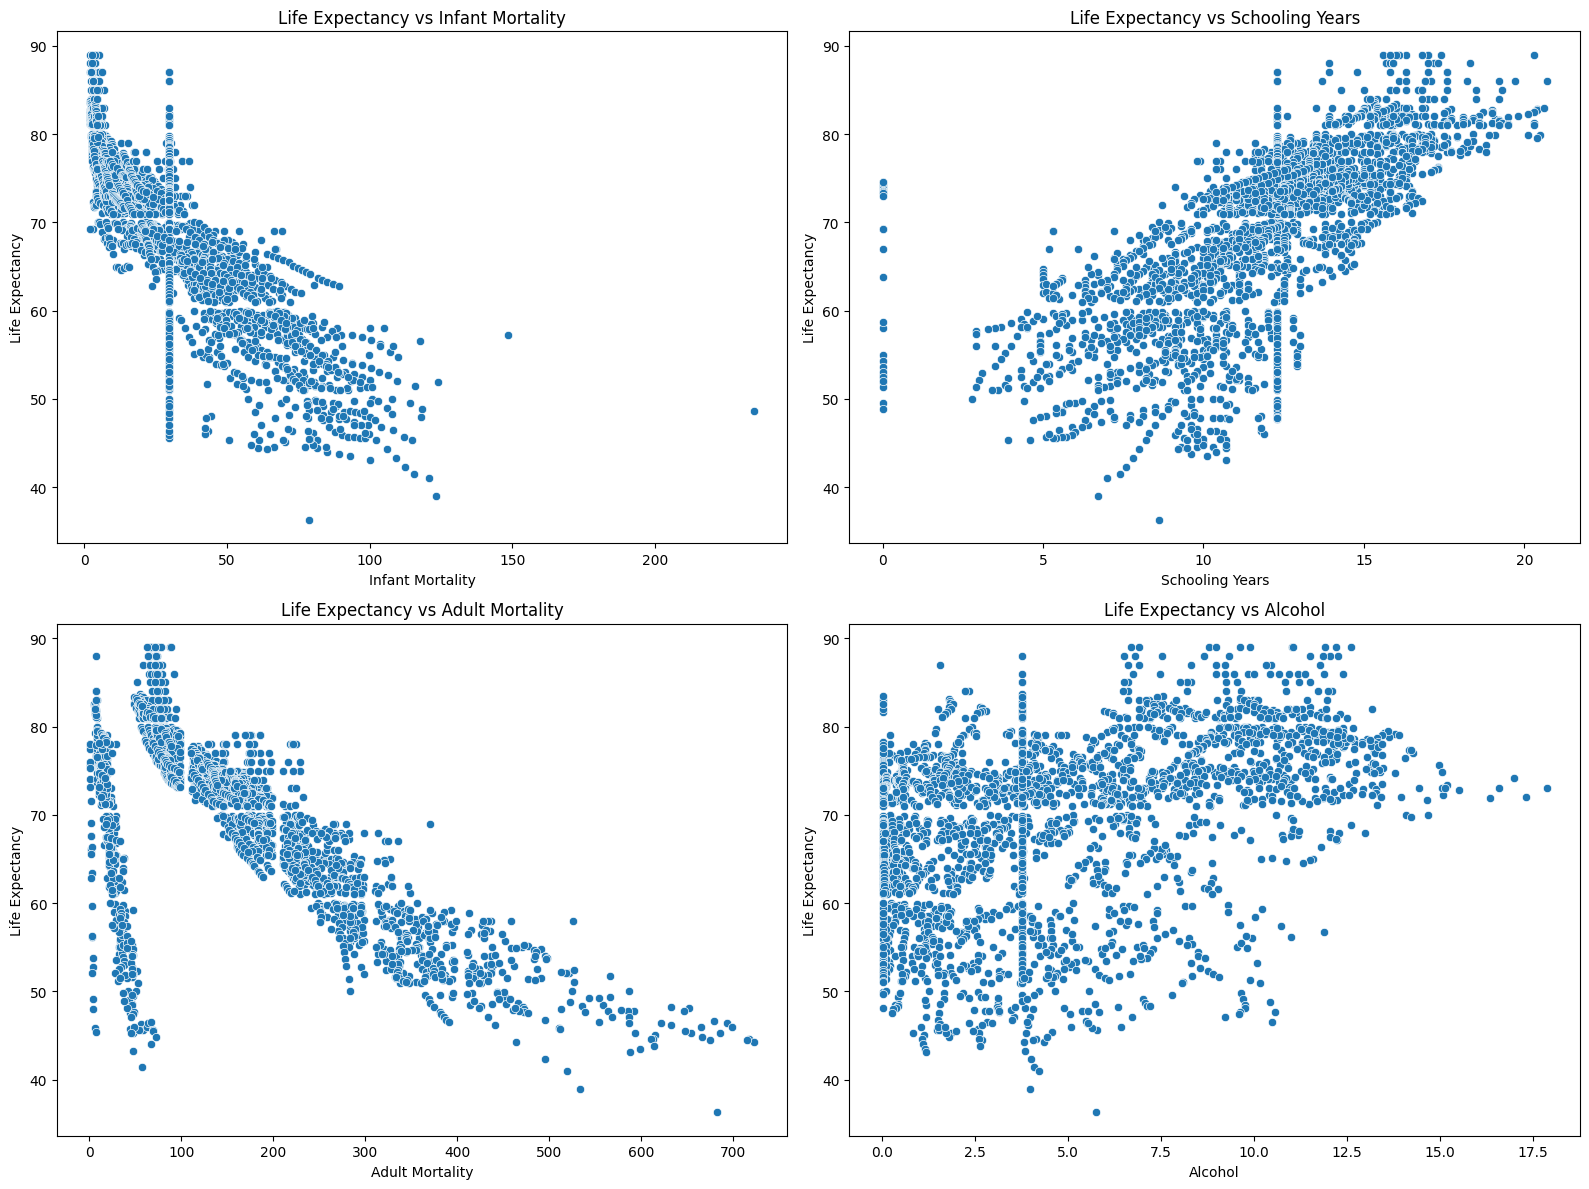

Scatter plots generated.


In [ ]:
print("Generating scatter plots...")

plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.scatterplot(x='infant_mortality', y='life_expectancy_', data=df)
plt.title('Life Expectancy vs Infant Mortality')
plt.xlabel('Infant Mortality')
plt.ylabel('Life Expectancy')

plt.subplot(2, 2, 2)
sns.scatterplot(x='schooling', y='life_expectancy_', data=df)
plt.title('Life Expectancy vs Schooling Years')
plt.xlabel('Schooling Years')
plt.ylabel('Life Expectancy')

plt.subplot(2, 2, 3)
sns.scatterplot(x='adult_mortality', y='life_expectancy_', data=df)
plt.title('Life Expectancy vs Adult Mortality')
plt.xlabel('Adult Mortality')
plt.ylabel('Life Expectancy')



plt.subplot(2, 2, 4)
sns.scatterplot(x='alcohol', y='life_expectancy_', data=df)
plt.title('Life Expectancy vs Alcohol')
plt.xlabel('Alcohol')
plt.ylabel('Life Expectancy')

plt.tight_layout()
plt.show()

print("Scatter plots generated.")

Generating correlation matrix heatmap...


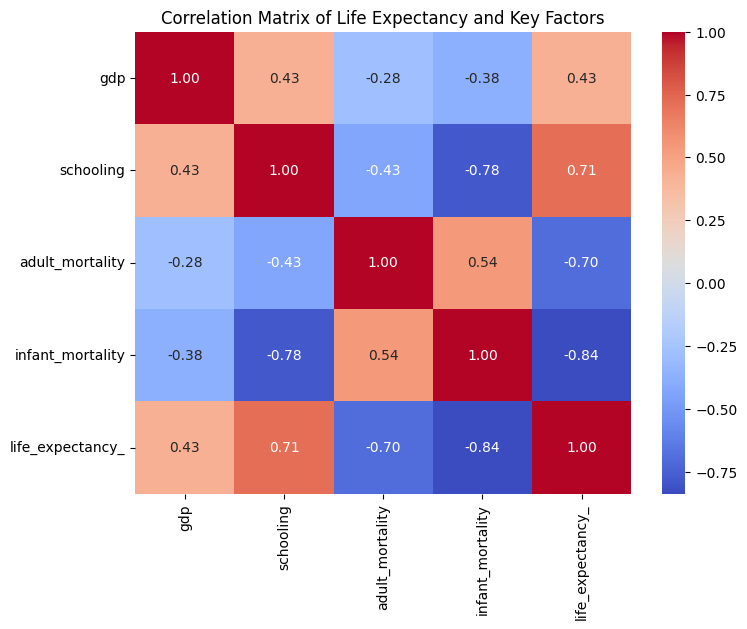

Correlation matrix heatmap generated.


In [ ]:
print("Generating correlation matrix heatmap...")

correlation_data = df[predictor_variables + [target_variable]]

corr_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Life Expectancy and Key Factors')
plt.show()

print("Correlation matrix heatmap generated.")

### Discussion of Life Expectancy Drivers and Answers to Questions

**1. Which factors most strongly correlate with life expectancy globally?**

Based on the Pearson correlation coefficients and the visualizations:

*   **Infant Mortality** shows the strongest negative correlation with life expectancy (-0.84).
*   **Schooling** shows the strongest positive correlation with life expectancy (0.71).
*   **Adult Mortality** shows a strong negative correlation (-0.70).
*   **GDP** shows a moderate positive correlation (0.43).

This indicates that lower infant mortality and higher schooling years are most strongly associated with higher life expectancy.

**2. Do countries with higher GDP have higher life expectancy?**

Yes, there is a positive correlation (0.43) between GDP and life expectancy. The scatter plot for 'Life Expectancy vs GDP' generally shows an upward trend, indicating that countries with higher GDP tend to have higher life expectancy. However, the relationship is not as strong or linear as with schooling or mortality rates, suggesting that while GDP is a factor, it doesn't entirely dictate life expectancy on its own.

**3. How do schooling years impact life expectancy?**

Schooling years have a strong positive impact on life expectancy, with a correlation coefficient of 0.71. The scatter plot for 'Life Expectancy vs Schooling Years' clearly shows that as schooling years increase, life expectancy generally increases significantly. This suggests that better education leads to improved health awareness, healthier lifestyles, and better access to healthcare information, all contributing to longer lives.

**4. Is adult mortality or infant mortality a stronger predictor of life expectancy?**

Comparing the absolute values of their correlation coefficients:

*   Infant Mortality: -0.84
*   Adult Mortality: -0.70

**Infant mortality** is a stronger negative predictor of life expectancy than adult mortality. A higher infant mortality rate is more strongly associated with a lower life expectancy. This highlights the critical importance of early-life health interventions and child survival rates in determining a population's overall life expectancy.

## Regional & Income Group Insights

### Subtask:
Analyze average life expectancy across different regions to identify the highest/lowest.


In [ ]:
print("\n" + "-" * 30 + "\n")
print("Calculating average life expectancy by region...")

average_life_expectancy_by_region = df.groupby('region')['life_expectancy_'].mean().sort_values(ascending=False)

print("Average Life Expectancy by Region (Highest to Lowest):")
print(average_life_expectancy_by_region)


------------------------------

Calculating average life expectancy by region...
Average Life Expectancy by Region (Highest to Lowest):
region
North America                 81.687500
Latin America & Caribbean     73.175599
Europe & Central Asia         73.155832
Middle East & North Africa    72.459868
East Asia & Pacific           71.548033
South Asia                    69.383333
Sub-Saharan Africa            57.077134
Name: life_expectancy_, dtype: float64



------------------------------

Generating bar chart for average life expectancy by region...


/tmp/ipython-input-2710497467.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_life_expectancy_by_region.index, y=average_life_expectancy_by_region.values, palette='viridis')


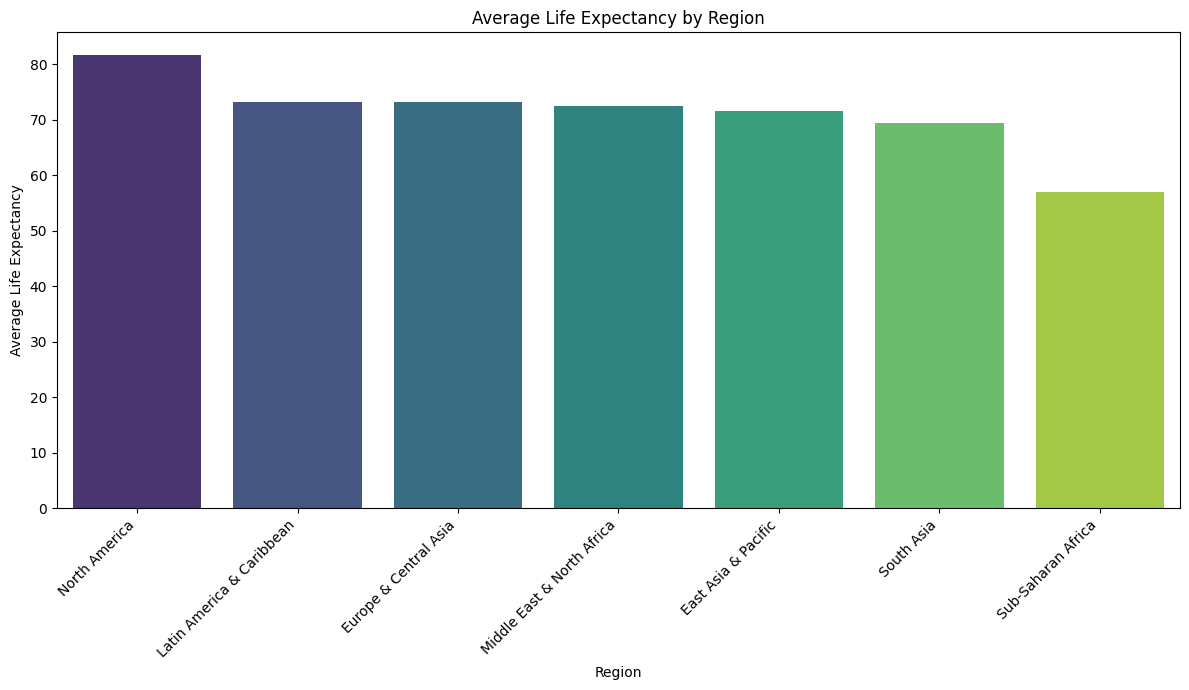

Bar chart for average life expectancy by region generated.


In [ ]:
print("\n" + "-" * 30 + "\n")
print("Generating bar chart for average life expectancy by region...")

plt.figure(figsize=(12, 7))
sns.barplot(x=average_life_expectancy_by_region.index, y=average_life_expectancy_by_region.values, palette='viridis')
plt.title('Average Life Expectancy by Region')
plt.xlabel('Region')
plt.ylabel('Average Life Expectancy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Bar chart for average life expectancy by region generated.")

## Regional & Income Group Insights

### Subtask:
Compare adult mortality, infant mortality, HIV/AIDS prevalence, and health expenditure between high-income and low-income groups.


In [ ]:
print("\n" + "-" * 30 + "\n")
print("Comparing health indicators between High and Low income groups...")

income_groups_of_interest = ['High income', 'Low income']
df_filtered_income = df[df['incomegroup'].isin(income_groups_of_interest)]

health_indicators_by_income_group = df_filtered_income.groupby('incomegroup')[['adult_mortality', 'infant_mortality', '_hiv/aids', 'total_expenditure']].mean()

print("Average Health Indicators by Income Group:")
print(health_indicators_by_income_group)


------------------------------

Comparing health indicators between High and Low income groups...
Average Health Indicators by Income Group:
             adult_mortality  infant_mortality  _hiv/aids  total_expenditure
incomegroup                                                                 
High income       120.807691         15.332636   0.797089           6.426707
Low income        267.212500         70.797500   3.986875           6.019016



------------------------------

Generating bar plots for health indicators by income group...


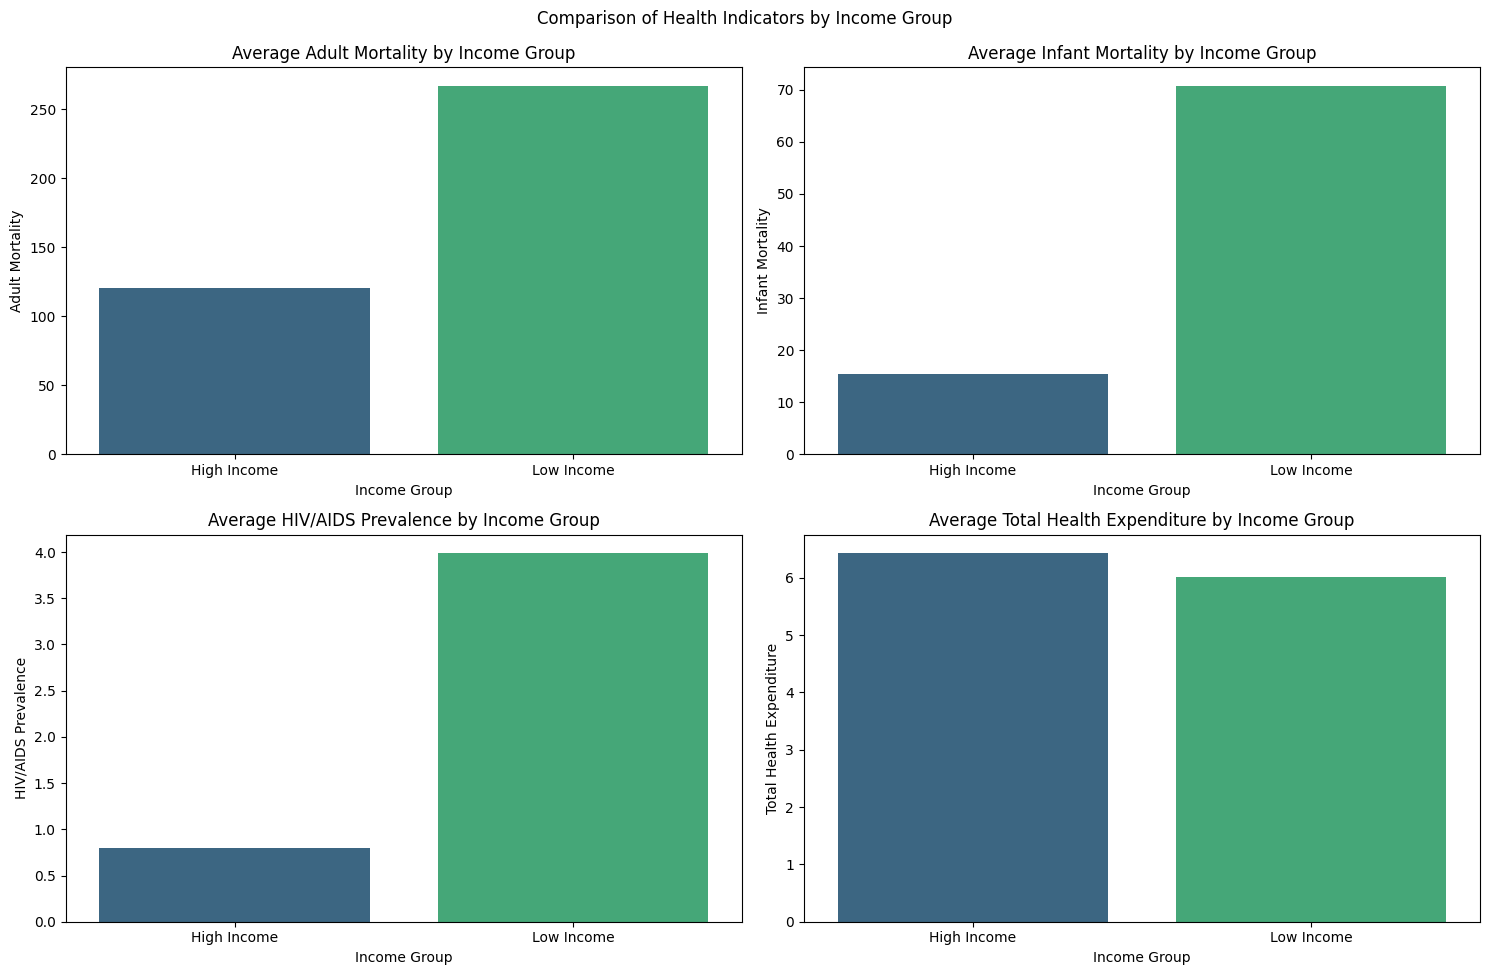

Bar plots for health indicators by income group generated.


In [ ]:
print("\n" + "-" * 30 + "\n")
print("Generating bar plots for health indicators by income group...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

indicators = ['adult_mortality', 'infant_mortality', '_hiv/aids', 'total_expenditure']
indicator_titles = {
    'adult_mortality': 'Adult Mortality',
    'infant_mortality': 'Infant Mortality',
    '_hiv/aids': 'HIV/AIDS Prevalence',
    'total_expenditure': 'Total Health Expenditure'
}

for i, indicator in enumerate(indicators):
    ax = axes[i]

    high_income_val = health_indicators_by_income_group.loc['High income', indicator]
    low_income_val = health_indicators_by_income_group.loc['Low income', indicator]

    sns.barplot(x=['High Income', 'Low Income'], y=[high_income_val, low_income_val], ax=ax, palette='viridis', hue=['High Income', 'Low Income'], legend=False)

    ax.set_title(f'Average {indicator_titles[indicator]} by Income Group')
    ax.set_ylabel(indicator_titles[indicator])
    ax.set_xlabel('Income Group')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.suptitle('Comparison of Health Indicators by Income Group', y=1.00)
plt.show()

print("Bar plots for health indicators by income group generated.")

## Investigate vaccination rates and health outcomes

### Subtask:
Investigate the correlation between vaccination rates (polio, diphtheria, hepatitis B) and lower infant deaths/higher life expectancy.


In [ ]:
print("\n" + "-" * 30 + "\n")
print("Calculating correlations between vaccination rates and life expectancy...")

vaccination_features = ['polio', 'diphtheria_', 'hepatitis_b']

life_expectancy_correlations = df[vaccination_features + ['life_expectancy_']].corr()['life_expectancy_'].drop('life_expectancy_')

print("Pearson Correlation Coefficients with Life Expectancy:")
print(life_expectancy_correlations)



------------------------------

Calculating correlations between vaccination rates and life expectancy...
Pearson Correlation Coefficients with Life Expectancy:
polio          0.458449
diphtheria_    0.472253
hepatitis_b    0.170555
Name: life_expectancy_, dtype: float64


## Analyze HIV/AIDS impact and disease correlation with child mortality

### Subtask:
Analyze how strongly HIV/AIDS indicators reduce life expectancy and identify which diseases strongly correlate with life_expectancy (under-five deaths).


In [ ]:
print("\n" + "-" * 30 + "\n")
print("Calculating correlations for HIV/AIDS impact and disease correlation with life_expectancy...")

hiv_life_expectancy_corr = df['_hiv/aids'].corr(df['life_expectancy_'])
print(f"Pearson Correlation between HIV/AIDS and Life Expectancy: {hiv_life_expectancy_corr:.2f}")



measles_under_five_deaths_corr = df['measles_'].corr(df['under_five_deaths_'])
print(f"Pearson Correlation between Measles and Under-five Deaths: {measles_under_five_deaths_corr:.2f}")



------------------------------

Calculating correlations for HIV/AIDS impact and disease correlation with life_expectancy...
Pearson Correlation between HIV/AIDS and Life Expectancy: -0.56
Pearson Correlation between Measles and Under-five Deaths: 0.51


## Identify and list the top 10 countries with the highest infant mortality.

### Subtask:
Identify the top 10 countries with the highest infant mortality rates and list them.


In [ ]:
print("\n" + "-" * 30 + "\n")
print("Identifying top 10 countries with highest infant mortality rates...")

country_infant_mortality = df.groupby('country')['infant_mortality'].mean()

top_10_infant_mortality = country_infant_mortality.sort_values(ascending=False).head(10)

print("Top 10 Countries with Highest Average Infant Mortality Rates:")
print(top_10_infant_mortality)

print("\n" + "-" * 30 + "\n")


------------------------------

Identifying top 10 countries with highest infant mortality rates...
Top 10 Countries with Highest Average Infant Mortality Rates:
country
Sierra Leone                99.80625
South Sudan                 97.62500
Central African Republic    97.53750
Chad                        87.71250
Afghanistan                 85.87500
Liberia                     83.95000
Mali                        83.66875
Equatorial Guinea           83.50000
Angola                      82.06875
Niger                       81.31250
Name: infant_mortality, dtype: float64

------------------------------



## Analyze trends of infant and under-five deaths over time

### Subtask:
Analyze trends of infant and under-five deaths over time to determine if they are decreasing.


In [ ]:
print("\n" + "-" * 30 + "\n")
print("Calculating average infant and under-five deaths by year...")

mortality_trends = df.groupby('year')[['infant_deaths', 'under_five_deaths_']].mean()

print("Average Infant and Under-five Deaths by Year:")
print(mortality_trends.head())
print(mortality_trends.tail())


------------------------------

Calculating average infant and under-five deaths by year...
Average Infant and Under-five Deaths by Year:
      infant_deaths  under_five_deaths_
year                                   
2000      37.540984           53.726776
2001      36.825137           52.038251
2002      35.584699           50.300546
2003      34.874317           48.584699
2004      33.644809           47.092896
      infant_deaths  under_five_deaths_
year                                   
2011      26.830601           36.918033
2012      26.338798           35.562842
2013      23.968912           32.419689
2014      24.557377           32.890710
2015      23.803279           31.612022



------------------------------

Generating line plots for mortality trends...


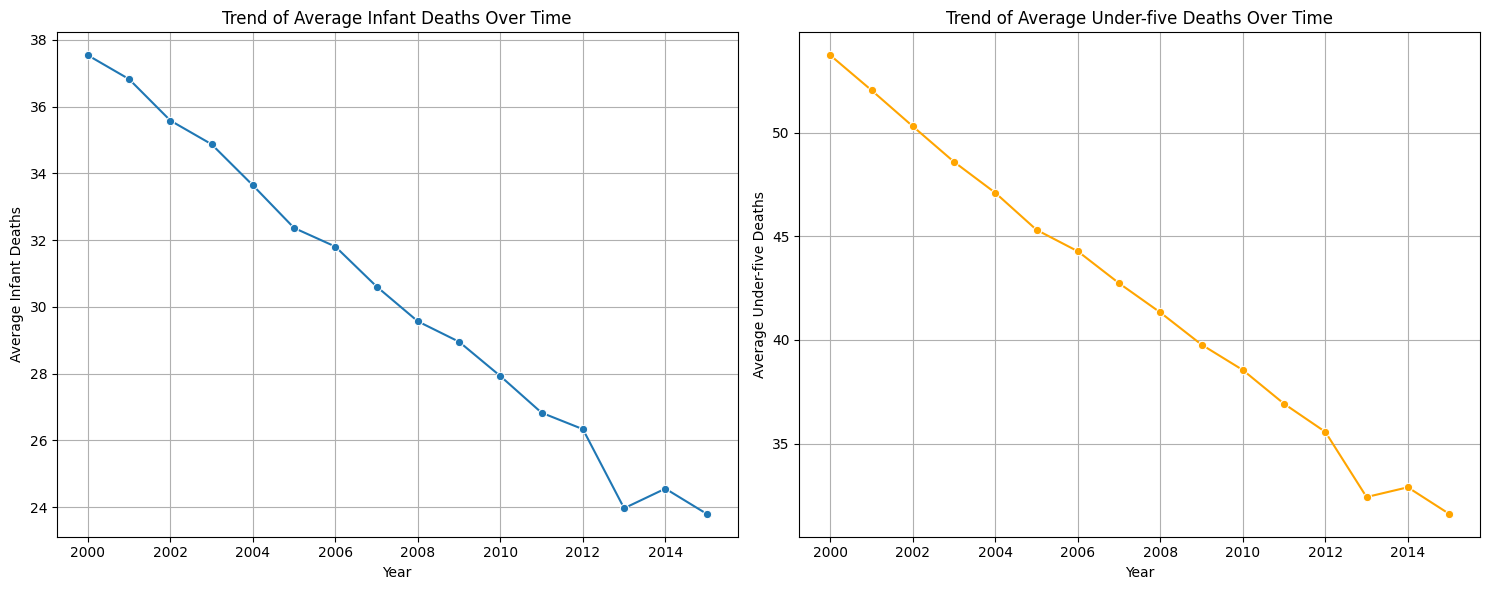

Line plots for mortality trends generated.


In [ ]:
print("\n" + "-" * 30 + "\n")
print("Generating line plots for mortality trends...")

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.lineplot(x=mortality_trends.index, y=mortality_trends['infant_deaths'], marker='o')
plt.title('Trend of Average Infant Deaths Over Time')
plt.xlabel('Year')
plt.ylabel('Average Infant Deaths')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.lineplot(x=mortality_trends.index, y=mortality_trends['under_five_deaths_'], marker='o', color='orange')
plt.title('Trend of Average Under-five Deaths Over Time')
plt.xlabel('Year')
plt.ylabel('Average Under-five Deaths')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Line plots for mortality trends generated.")

## Examine whether higher health expenditure reduces adult mortality and infant mortality.

### Subtask:
Examine whether higher health expenditure reduces adult mortality and infant mortality by calculating and visualizing their correlations.


In [ ]:
print("\n" + "-" * 30 + "\n")
print("Calculating correlations between total health expenditure and mortality rates...")

correlation_expenditure_adult_mortality = df['total_expenditure'].corr(df['adult_mortality'])

correlation_expenditure_infant_mortality = df['total_expenditure'].corr(df['infant_mortality'])

print(f"Pearson Correlation between Total Expenditure and Adult Mortality: {correlation_expenditure_adult_mortality:.2f}")
print(f"Pearson Correlation between Total Expenditure and Infant Mortality: {correlation_expenditure_infant_mortality:.2f}")


------------------------------

Calculating correlations between total health expenditure and mortality rates...
Pearson Correlation between Total Expenditure and Adult Mortality: -0.11
Pearson Correlation between Total Expenditure and Infant Mortality: -0.15



------------------------------

Generating scatter plots for health expenditure and mortality rates...


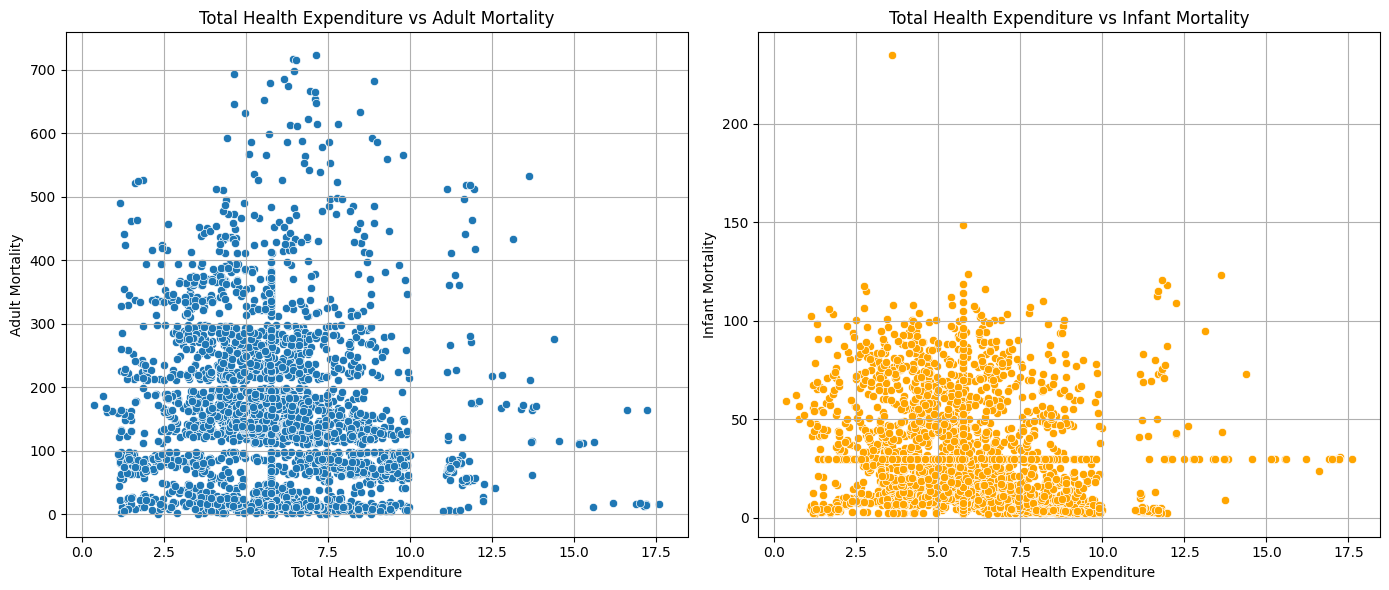

Scatter plots generated.


In [ ]:
print("\n" + "-" * 30 + "\n")
print("Generating scatter plots for health expenditure and mortality rates...")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='total_expenditure', y='adult_mortality', data=df)
plt.title('Total Health Expenditure vs Adult Mortality')
plt.xlabel('Total Health Expenditure')
plt.ylabel('Adult Mortality')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x='total_expenditure', y='infant_mortality', data=df, color='orange')
plt.title('Total Health Expenditure vs Infant Mortality')
plt.xlabel('Total Health Expenditure')
plt.ylabel('Infant Mortality')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Scatter plots generated.")


------------------------------

Generating comprehensive visualizations of key findings...


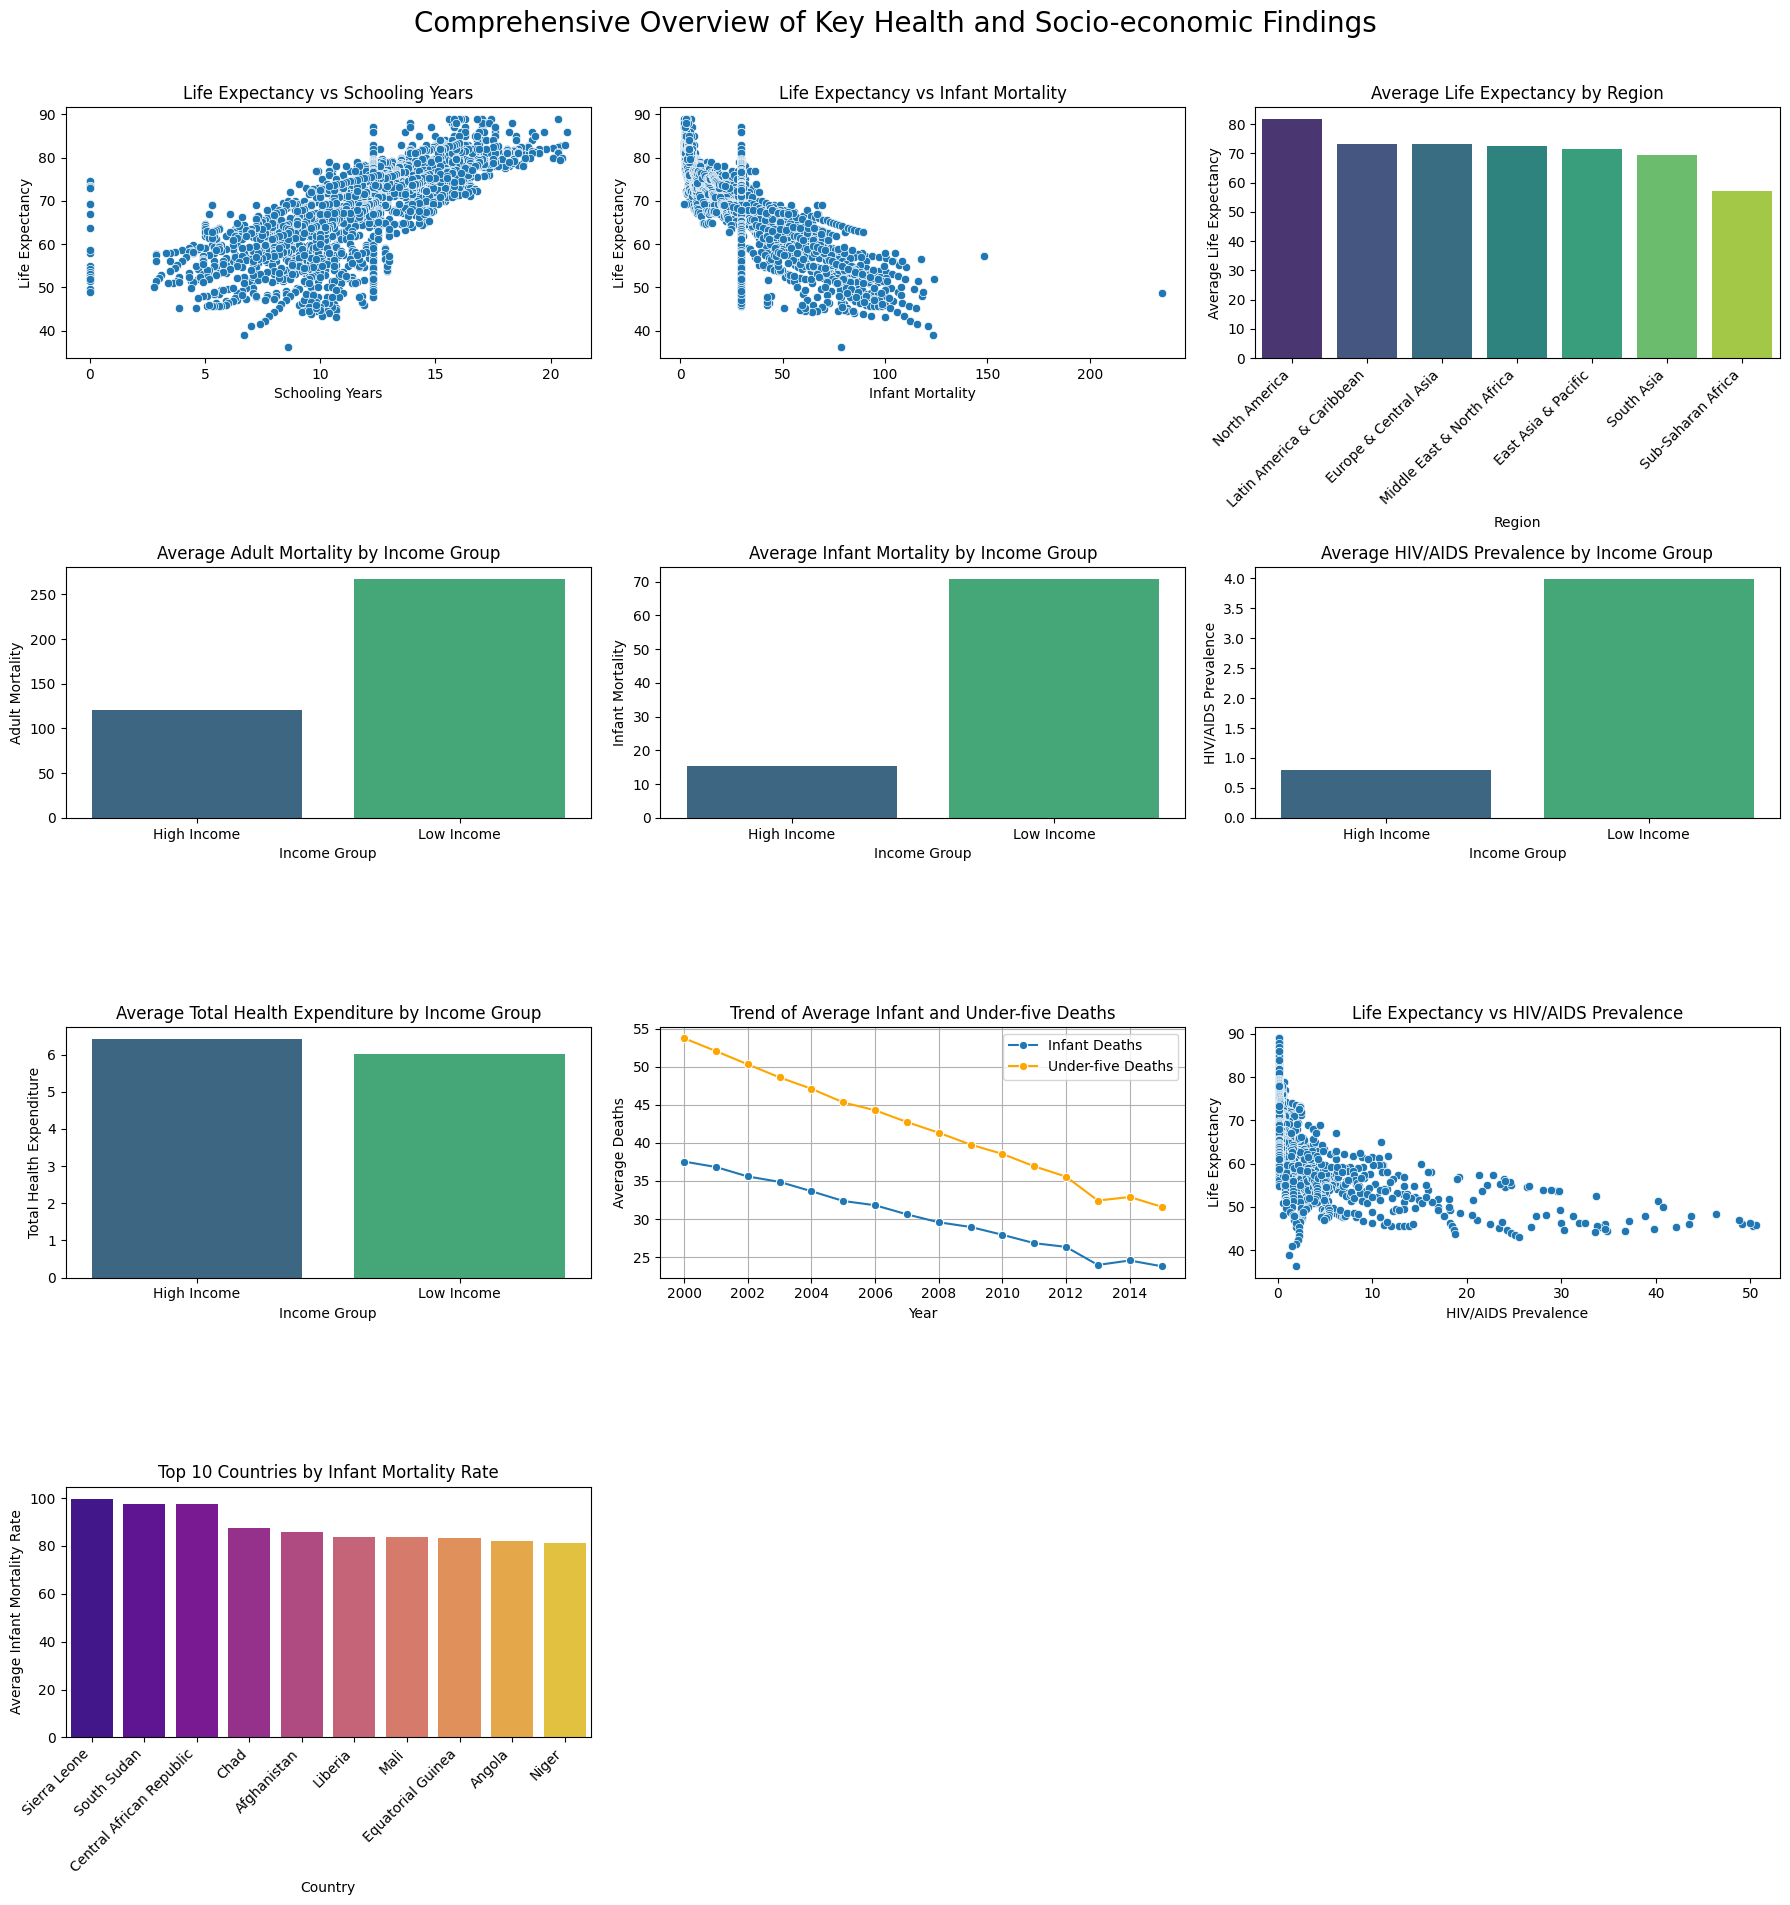

Comprehensive visualizations generated.


In [ ]:
print("\n" + "-" * 30 + "\n")
print("Generating comprehensive visualizations of key findings...")

num_rows = 4
num_cols = 3
plt.figure(figsize=(num_cols * 6, num_rows * 5))

plt.subplot(num_rows, num_cols, 1)
sns.scatterplot(x='schooling', y='life_expectancy_', data=df)
plt.title('Life Expectancy vs Schooling Years')
plt.xlabel('Schooling Years')
plt.ylabel('Life Expectancy')

plt.subplot(num_rows, num_cols, 2)
sns.scatterplot(x='infant_mortality', y='life_expectancy_', data=df)
plt.title('Life Expectancy vs Infant Mortality')
plt.xlabel('Infant Mortality')
plt.ylabel('Life Expectancy')

plt.subplot(num_rows, num_cols, 3)
sns.barplot(x=average_life_expectancy_by_region.index, y=average_life_expectancy_by_region.values, palette='viridis', hue=average_life_expectancy_by_region.index, legend=False)
plt.title('Average Life Expectancy by Region')
plt.xlabel('Region')
plt.ylabel('Average Life Expectancy')
plt.xticks(rotation=45, ha='right')

indicators = ['adult_mortality', 'infant_mortality', '_hiv/aids', 'total_expenditure']
indicator_titles = {
    'adult_mortality': 'Adult Mortality',
    'infant_mortality': 'Infant Mortality',
    '_hiv/aids': 'HIV/AIDS Prevalence',
    'total_expenditure': 'Total Health Expenditure'
}

start_plot_idx = 4
for i, indicator in enumerate(indicators):
    ax = plt.subplot(num_rows, num_cols, start_plot_idx + i)
    high_income_val = health_indicators_by_income_group.loc['High income', indicator]
    low_income_val = health_indicators_by_income_group.loc['Low income', indicator]
    sns.barplot(x=['High Income', 'Low Income'], y=[high_income_val, low_income_val], ax=ax, palette='viridis', hue=['High Income', 'Low Income'], legend=False)
    ax.set_title(f'Average {indicator_titles[indicator]} by Income Group')
    ax.set_ylabel(indicator_titles[indicator])
    ax.set_xlabel('Income Group')

plt.subplot(num_rows, num_cols, 8)
sns.lineplot(x=mortality_trends.index, y=mortality_trends['infant_deaths'], marker='o', label='Infant Deaths')
sns.lineplot(x=mortality_trends.index, y=mortality_trends['under_five_deaths_'], marker='o', color='orange', label='Under-five Deaths')
plt.title('Trend of Average Infant and Under-five Deaths')
plt.xlabel('Year')
plt.ylabel('Average Deaths')
plt.legend()
plt.grid(True)

plt.subplot(num_rows, num_cols, 9)
sns.scatterplot(x='_hiv/aids', y='life_expectancy_', data=df)
plt.title('Life Expectancy vs HIV/AIDS Prevalence')
plt.xlabel('HIV/AIDS Prevalence')
plt.ylabel('Life Expectancy')

plt.subplot(num_rows, num_cols, 10)
sns.barplot(x=top_10_infant_mortality.index, y=top_10_infant_mortality.values, palette='plasma', hue=top_10_infant_mortality.index, legend=False)
plt.title('Top 10 Countries by Infant Mortality Rate')
plt.xlabel('Country')
plt.ylabel('Average Infant Mortality Rate')
plt.xticks(rotation=45, ha='right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Comprehensive Overview of Key Health and Socio-economic Findings', y=0.98, fontsize=20)
plt.show()

print("Comprehensive visualizations generated.")

## Summary of Key Insights (Q&A Format)

**Q1: Which factors most strongly correlate with life expectancy globally?**
**A1:** The strongest correlates with life expectancy are **infant mortality** (strongest negative correlation: -0.84) and **schooling years** (strongest positive correlation: 0.71). Adult mortality also shows a strong negative correlation (-0.70), while GDP has a moderate positive correlation (0.43).

**Q2: Do countries with higher GDP necessarily have higher life expectancy?**
**A2:** Yes, there is a positive correlation (0.43) between GDP and life expectancy, indicating that higher GDP generally aligns with higher life expectancy. However, this relationship is not as strong as with schooling or mortality rates, suggesting other factors play a more dominant role.

**Q3: How do schooling years impact life expectancy?**
**A3:** Schooling years have a strong positive impact, with a correlation of 0.71. Increased schooling is strongly associated with higher life expectancy, likely due to improved health awareness, healthier lifestyles, and better access to healthcare information.

**Q4: Is adult mortality or infant mortality a stronger predictor of life expectancy?**
**A4:** **Infant mortality** is a stronger negative predictor of life expectancy (-0.84) compared to adult mortality (-0.70). This highlights the critical importance of early-life health interventions in determining overall population life expectancy.

**Q5: Which regions have the highest and lowest average life expectancy?**
**A5:** **North America** has the highest average life expectancy (81.69 years), while **Sub-Saharan Africa** has the lowest (57.08 years).

**Q6: How do key health indicators compare between High-income and Low-income groups?**
**A6:** High-income countries have significantly lower average adult mortality (120.81 vs. 267.21) and infant mortality (15.33 vs. 70.80) rates. Low-income countries, however, show a higher average HIV/AIDS prevalence (3.99% vs. 0.80%). Total health expenditure, as a percentage, is slightly higher in high-income countries (6.43% vs. 6.02%).

**Q7: What is the correlation between vaccination rates (polio, diphtheria, hepatitis B) and life expectancy?**
**A7:** Polio (0.46) and Diphtheria (0.47) vaccination rates show moderate positive correlations with life expectancy. Hepatitis B has a weaker positive correlation (0.17).

**Q8: How strongly does HIV/AIDS prevalence reduce life expectancy, and which diseases correlate with child mortality?**
**A8:** There is a strong negative correlation between **HIV/AIDS prevalence** and life expectancy (-0.56). **Measles incidence** shows a positive correlation with under-five deaths (0.51).

**Q9: Which are the top 10 countries with the highest infant mortality rates?**
**A9:** The top 10 countries with the highest average infant mortality rates are Sierra Leone, South Sudan, Central African Republic, Chad, Afghanistan, Liberia, Mali, Equatorial Guinea, Angola, and Niger.

**Q10: Are infant and under-five deaths decreasing over time?**
**A10:** Yes, the analysis of trends from 2000 to 2015 indicates a general decreasing trend in both average infant deaths and under-five deaths over time.

**Q11: Does higher health expenditure reduce adult and infant mortality?**
**A11:** Total health expenditure shows weak negative correlations with both adult mortality (-0.11) and infant mortality (-0.15). While there's a slight inverse relationship, this suggests that increased expenditure, in isolation, is not a strong predictor of lower mortality rates based on this dataset.

# Task
## Expanded Analysis of Health Indicators Across All Four Key Income Groups

The previous analysis compared health indicators only between high and low-income groups. To provide a more comprehensive understanding, let's expand the comparison to include 'Lower middle income' and 'Upper middle income' groups as well.

### **Plan:**
* **Filter Data by Income Groups**: Filter the DataFrame to include 'High income', 'Low income', 'Lower middle income', and 'Upper middle income' groups.
* **Calculate Average Health Indicators**: Group the filtered DataFrame by 'incomegroup' and calculate the mean for key health indicators: 'adult_mortality', 'infant_mortality', '_hiv/aids', and 'total_expenditure'.
* **Generate Bar Plots for All Income Groups**: Create a series of bar plots, one for each health indicator, comparing the average values across all four selected income groups ('High income', 'Low income', 'Lower middle income', and 'Upper middle income'). Make sure to add appropriate titles and labels, and include legends if necessary to distinguish the income groups.
* **Summarize Expanded Findings**: Provide a detailed summary of the findings from the expanded analysis, highlighting any new insights or trends observed across the four income groups for adult mortality, infant mortality, HIV/AIDS prevalence, and total health expenditure. Focus on the differences and similarities between all four groups.
* **Final Task**: Summarize the key insights and findings from the expanded analysis of health indicators across all four income groups (High, Low, Lower Middle, and Upper Middle Income).

**Action**: Filter the data to include the specified income groups and calculate the average health indicators for each group.
I will begin by extracting the filtered data and then compute the average health indicators.
```python
print("\n" + "-" * 30 + "\n")
print("Expanding comparison of health indicators to include 'Lower middle income' and 'Upper middle income' groups...")

# Filter the DataFrame to include the four specified income groups
all_income_groups = ['High income', 'Low income', 'Lower middle income', 'Upper middle income']
df_filtered_all_income = df[df['incomegroup'].isin(all_income_groups)]

# Calculate the mean for key health indicators for all four income groups
health_indicators_all_income_groups = df_filtered_all_income.groupby('incomegroup')[['adult_mortality', 'infant_mortality', '_hiv/aids', 'total_expenditure']].mean()

print("Average Health Indicators by Income Group (including Lower and Upper Middle Income):")
print(health_indicators_all_income_groups)
```

## Filter Data by Income Groups

### Subtask:
Filter the DataFrame to include 'High income', 'Low income', 'Lower middle income', and 'Upper middle income' groups, and then calculate the average for key health indicators within these groups.


**Reasoning**:
I will define the income groups, filter the DataFrame, group it by income group, and calculate the mean of the specified health indicators to compare them across all relevant income groups.



**Reasoning**:
The previous code failed because the DataFrame `df` was not defined in the current execution context, leading to a `NameError`. This can happen if preceding cells where `df` was loaded and processed were not executed. To fix this, I will include the necessary data loading and preprocessing steps (from cells M9d7fsCNnA8L and 6aBo2Ygfnk_n) within this code block to ensure `df` is properly initialized and cleaned before performing the requested analysis.



In [ ]:
import pandas as pd

# Re-load the DataFrame as it was not defined in the current context
df = pd.read_csv('/content/combined_life_expectancy_mortality_data.csv')

# Re-apply cleaning steps from previous cells to ensure df is ready
columns_to_drop = ['unnamed:_5', 'specialnotes']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

print("\n" + "-" * 30 + "\n")
print("Filtering data and calculating average health indicators for all relevant income groups...")

all_income_groups = ['High income', 'Low income', 'Lower middle income', 'Upper middle income']
df_filtered_all_income = df[df['incomegroup'].isin(all_income_groups)]

health_indicators_all_income_groups = df_filtered_all_income.groupby('incomegroup')[['adult_mortality', 'infant_mortality', '_hiv/aids', 'total_expenditure']].mean()

print("Average Health Indicators by All Relevant Income Groups:")
print(health_indicators_all_income_groups)


------------------------------

Filtering data and calculating average health indicators for all relevant income groups...
Average Health Indicators by All Relevant Income Groups:
                     adult_mortality  infant_mortality  _hiv/aids  \
incomegroup                                                         
High income               120.807691         15.332636   0.797089   
Low income                267.212500         70.797500   3.986875   
Lower middle income       212.718750         45.972061   2.979062   
Upper middle income       154.140579         21.786704   1.305233   

                     total_expenditure  
incomegroup                             
High income                   6.426707  
Low income                    6.019016  
Lower middle income           5.248000  
Upper middle income           5.589604  


**Reasoning**:
The previous code failed with a FileNotFoundError because the specified CSV file could not be found. This suggests that either the file was deleted or the notebook environment was reset, losing the `df` variable and access to the file. To resolve this, the code must re-load the data from the CSV file and re-apply the necessary cleaning steps to initialize the `df` DataFrame correctly before performing the requested analysis. I will use the path `/content/combined_life_expectancy_mortality_data.csv`, assuming the user ensures the file is present and accessible at this location.



In [ ]:
import pandas as pd

# Re-load the DataFrame as it was not defined in the current context
df = pd.read_csv('/content/combined_life_expectancy_mortality_data.csv')

# Re-apply cleaning steps from previous cells to ensure df is ready
columns_to_drop = ['unnamed:_5', 'specialnotes']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

print("\n" + "-" * 30 + "\n")
print("Filtering data and calculating average health indicators for all relevant income groups...")

all_income_groups = ['High income', 'Low income', 'Lower middle income', 'Upper middle income']
df_filtered_all_income = df[df['incomegroup'].isin(all_income_groups)]

health_indicators_all_income_groups = df_filtered_all_income.groupby('incomegroup')[['adult_mortality', 'infant_mortality', '_hiv/aids', 'total_expenditure']].mean()

print("Average Health Indicators by All Relevant Income Groups:")
print(health_indicators_all_income_groups)


------------------------------

Filtering data and calculating average health indicators for all relevant income groups...
Average Health Indicators by All Relevant Income Groups:
                     adult_mortality  infant_mortality  _hiv/aids  \
incomegroup                                                         
High income               120.807691         15.332636   0.797089   
Low income                267.212500         70.797500   3.986875   
Lower middle income       212.718750         45.972061   2.979062   
Upper middle income       154.140579         21.786704   1.305233   

                     total_expenditure  
incomegroup                             
High income                   6.426707  
Low income                    6.019016  
Lower middle income           5.248000  
Upper middle income           5.589604  


**Reasoning**:
The previous step successfully calculated the average health indicators for all four income groups. Now, I will visualize these averages using bar plots to provide a clear comparison across income groups for each health indicator as outlined in the subtask instructions.



**Reasoning**:
The previous code failed because `ha` (horizontal alignment) is not a recognized keyword argument for `ax.tick_params`. I will remove `ha='right'` from the `tick_params` call, as rotation typically handles label placement sufficiently.




------------------------------

Generating bar plots for health indicators across all four income groups...


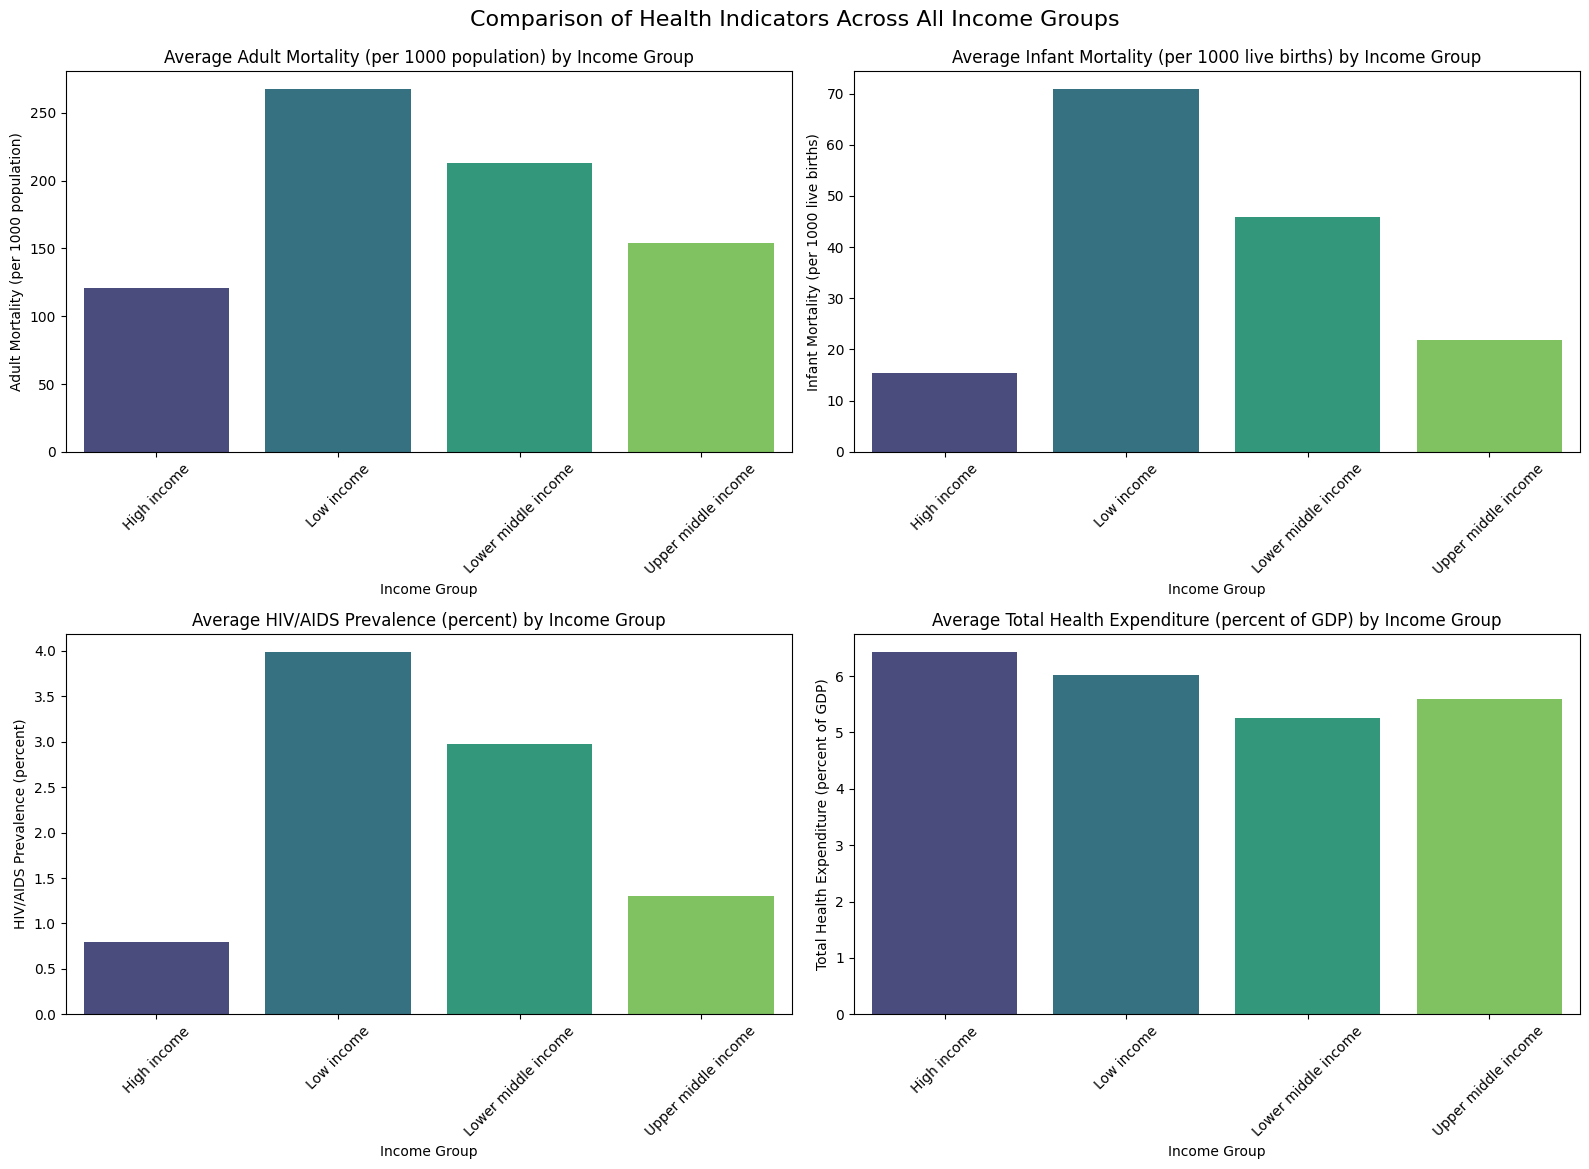

Bar plots for health indicators across all income groups generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "-" * 30 + "\n")
print("Generating bar plots for health indicators across all four income groups...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

indicators = ['adult_mortality', 'infant_mortality', '_hiv/aids', 'total_expenditure']
indicator_titles = {
    'adult_mortality': 'Adult Mortality (per 1000 population)',
    'infant_mortality': 'Infant Mortality (per 1000 live births)',
    '_hiv/aids': 'HIV/AIDS Prevalence (percent)',
    'total_expenditure': 'Total Health Expenditure (percent of GDP)'
}

for i, indicator in enumerate(indicators):
    ax = axes[i]
    sns.barplot(x=health_indicators_all_income_groups.index, y=health_indicators_all_income_groups[indicator], ax=ax, palette='viridis', hue=health_indicators_all_income_groups.index, legend=False)
    ax.set_title(f'Average {indicator_titles[indicator]} by Income Group')
    ax.set_ylabel(indicator_titles[indicator])
    ax.set_xlabel('Income Group')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.suptitle('Comparison of Health Indicators Across All Income Groups', y=1.00, fontsize=16)
plt.show()

print("Bar plots for health indicators across all income groups generated.")

### Summary of Expanded Findings Across All Four Income Groups

The expanded analysis provides a more granular view of health indicators across 'High income', 'Upper middle income', 'Lower middle income', and 'Low income' groups.

**1. Adult Mortality:**
*   **High Income** countries show the lowest average adult mortality (120.81 per 1000 population).
*   **Upper Middle Income** countries follow with a moderately higher rate (154.14).
*   **Lower Middle Income** countries have a significantly higher rate (212.72).
*   **Low Income** countries exhibit the highest average adult mortality (267.21). This clearly demonstrates a strong inverse relationship between income level and adult mortality, where higher income correlates with lower mortality.

**2. Infant Mortality:**
*   Similar to adult mortality, **High Income** countries have the lowest average infant mortality (15.33 per 1000 live births).
*   **Upper Middle Income** countries have a slightly higher rate (21.79).
*   **Lower Middle Income** countries show a substantial increase (45.97).
*   **Low Income** countries experience the highest average infant mortality (70.80). This pattern reinforces the idea that economic prosperity is a critical factor in child survival rates.

**3. HIV/AIDS Prevalence:**
*   **High Income** countries have the lowest HIV/AIDS prevalence (0.80%).
*   **Upper Middle Income** countries show a slightly higher prevalence (1.31%).
*   **Lower Middle Income** countries have a considerably higher prevalence (2.98%).
*   **Low Income** countries report the highest average HIV/AIDS prevalence (3.99%). This indicates that lower income groups generally face a greater burden from HIV/AIDS.

**4. Total Health Expenditure (as % of GDP):**
*   **High Income** countries have the highest average total health expenditure (6.43% of GDP).
*   **Low Income** countries surprisingly show the second highest average expenditure (6.02%), though this could be due to external aid or a smaller GDP base making the percentage appear higher for potentially lower absolute spending.
*   **Upper Middle Income** countries follow with 5.59%.
*   **Lower Middle Income** countries have the lowest average total health expenditure (5.25%). The relationship here is not as strictly linear with income as the mortality and prevalence rates, suggesting that how funds are allocated and the efficiency of healthcare systems might also play significant roles.

**Overall Insights:**
There is a clear and consistent trend: as income level decreases from high to low, adult mortality, infant mortality, and HIV/AIDS prevalence generally increase significantly. This underscores the profound impact of socio-economic development on public health outcomes. While health expenditure generally correlates positively with income for high-income groups, the pattern is less clear for lower-income categories, where the percentage of GDP spent on health might not directly translate to better outcomes due to various other factors such as infrastructure, access, and governance.

## Final Task

### Subtask:
Summarize the key insights and findings from the expanded analysis of health indicators across all four income groups (High, Low, Lower Middle, and Upper Middle Income).


## Summary:

### Q&A
The key insights and findings from the expanded analysis of health indicators across all four income groups (High, Low, Lower Middle, and Upper Middle Income) reveal a clear correlation between income level and health outcomes. Generally, as income decreases, health indicators such as adult mortality, infant mortality, and HIV/AIDS prevalence worsen. Total health expenditure, however, shows a less linear relationship, suggesting other factors like spending efficiency play a significant role.

### Data Analysis Key Findings
*   **Adult Mortality:** High-income countries exhibit the lowest average adult mortality at 120.81 per 1000 population, while low-income countries have the highest at 267.21. Upper middle-income countries report 154.14, and lower middle-income countries show 212.72.
*   **Infant Mortality:** High-income countries record the lowest average infant mortality at 15.33 per 1000 live births. This rate progressively increases through upper middle-income (21.79) and lower middle-income (45.97) groups, peaking in low-income countries at 70.80.
*   **HIV/AIDS Prevalence:** High-income countries demonstrate the lowest HIV/AIDS prevalence at 0.80%. Prevalence increases with decreasing income, reaching 1.31% in upper middle-income, 2.98% in lower middle-income, and 3.99% in low-income countries.
*   **Total Health Expenditure:** High-income countries have the highest average total health expenditure as a percentage of GDP, at 6.43%. Surprisingly, low-income countries rank second highest at 6.02%. Upper middle-income countries spend 5.59%, and lower middle-income countries have the lowest expenditure at 5.25%.

### Insights or Next Steps
*   The strong inverse relationship between income levels and mortality (adult and infant) and HIV/AIDS prevalence highlights the profound impact of socio-economic development on public health outcomes.
*   The non-linear pattern of total health expenditure as a percentage of GDP suggests that simply increasing spending might not suffice; the efficiency of healthcare systems, resource allocation, and external aid for lower-income countries likely play crucial roles. Further investigation into the effectiveness and allocation of health expenditure within different income groups could provide deeper insights.
